In [2]:
import pandas as pd
breast_cancer_data = "./breast-cancer-data-normal.csv"
dataset_path = "/Users/ali/Desktop/Codes/ml_ui/t1/mlui_flask/uploads/03626d1ef4d542ac94468828ea202d17/df4425977a3c4896bae3b20597f6782e_diabetes_data 2.csv"
dataset = pd.read_csv(breast_cancer_data)
target_column = "diagnosis"

In [3]:
dataset

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,1,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.30010,0.14710,...,17.33,184.60,2019.0,0.16220,0.66560,0.7119,0.2654,0.4601,0.11890,NaN
1,842517,1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.08690,0.07017,...,23.41,158.80,1956.0,0.12380,0.18660,0.2416,0.1860,0.2750,0.08902,NaN
2,84300903,1,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.19740,0.12790,...,25.53,152.50,1709.0,0.14440,0.42450,0.4504,0.2430,0.3613,0.08758,NaN
3,84348301,1,11.42,20.38,77.58,386.1,0.14250,0.28390,0.24140,0.10520,...,26.50,98.87,567.7,0.20980,0.86630,0.6869,0.2575,0.6638,0.17300,NaN
4,84358402,1,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.19800,0.10430,...,16.67,152.20,1575.0,0.13740,0.20500,0.4000,0.1625,0.2364,0.07678,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
564,926424,1,21.56,22.39,142.00,1479.0,0.11100,0.11590,0.24390,0.13890,...,26.40,166.10,2027.0,0.14100,0.21130,0.4107,0.2216,0.2060,0.07115,NaN
565,926682,1,20.13,28.25,131.20,1261.0,0.09780,0.10340,0.14400,0.09791,...,38.25,155.00,1731.0,0.11660,0.19220,0.3215,0.1628,0.2572,0.06637,NaN
566,926954,1,16.60,28.08,108.30,858.1,0.08455,0.10230,0.09251,0.05302,...,34.12,126.70,1124.0,0.11390,0.30940,0.3403,0.1418,0.2218,0.07820,NaN
567,927241,1,20.60,29.33,140.10,1265.0,0.11780,0.27700,0.35140,0.15200,...,39.42,184.60,1821.0,0.16500,0.86810,0.9387,0.2650,0.4087,0.12400,NaN


In [98]:
dataset_size = dataset.shape[0]
dataset_size

569

In [122]:
summary_stats = dataset.describe()
missing_values = dataset.isnull().sum()
noisiness_score = (summary_stats.std() + missing_values / dataset.shape[0])

In [131]:
# noisiness_score > 2
filtered_dict = {key: value for key, value in missing_values.items() if value > 2}
filtered_dict
# missing_values
# [(missing_values > 0)]

{'Unnamed: 32': 569}

In [101]:
missing_values

id                           0
diagnosis                    0
radius_mean                  0
texture_mean                 0
perimeter_mean               0
area_mean                    0
smoothness_mean              0
compactness_mean             0
concavity_mean               0
concave points_mean          0
symmetry_mean                0
fractal_dimension_mean       0
radius_se                    0
texture_se                   0
perimeter_se                 0
area_se                      0
smoothness_se                0
compactness_se               0
concavity_se                 0
concave points_se            0
symmetry_se                  0
fractal_dimension_se         0
radius_worst                 0
texture_worst                0
perimeter_worst              0
area_worst                   0
smoothness_worst             0
compactness_worst            0
concavity_worst              0
concave points_worst         0
symmetry_worst               0
fractal_dimension_worst      0
Unnamed:

In [102]:
noisiness_score

id                         3.166932e+08
diagnosis                  2.010280e+02
radius_mean                1.965771e+02
texture_mean               1.949035e+02
perimeter_mean             1.769697e+02
area_mean                  7.351747e+02
smoothness_mean            2.011409e+02
compactness_mean           2.011310e+02
concavity_mean             2.011307e+02
concave points_mean        2.011508e+02
symmetry_mean              2.011135e+02
fractal_dimension_mean     2.011515e+02
radius_se                  2.009364e+02
texture_se                 2.006502e+02
perimeter_se               1.995327e+02
area_se                    2.437747e+02
smoothness_se              2.011687e+02
compactness_se             2.011594e+02
concavity_se               2.011446e+02
concave points_se          2.011666e+02
symmetry_se                2.011631e+02
fractal_dimension_se       2.011695e+02
radius_worst               1.957454e+02
texture_worst              1.930359e+02
perimeter_worst            1.760772e+02


In [103]:
import numpy as np
z_score_threshold=3
missing_threshold=0.1
# Check for missing values
missing_percentages = dataset.isnull().mean()

# Identify features with high missing percentages
noisy_features_missing = missing_percentages[missing_percentages > missing_threshold].index.tolist()

# Calculate Z-scores for numerical features
z_scores = pd.DataFrame()
for col in dataset.select_dtypes(include=np.number).columns:
    z_scores[col] = np.abs((dataset[col] - dataset[col].mean()) / dataset[col].std())

# Identify features with high Z-scores
noisy_features_z_score = z_scores.columns[z_scores.max() > z_score_threshold].tolist()

# Combine features identified as noisy
noisy_features = list(set(noisy_features_missing + noisy_features_z_score))

# Determine if the dataset is noisy based on identified features
noisy = len(noisy_features) > 0

# noisy_features_missing
# noisy_features_z_score
z_scores
# noisy
# noisy_features

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,0.236197,1.296535,1.096100,2.071512,1.268817,0.983510,1.567087,3.280628,2.650542,2.530249,...,1.358098,2.301575,1.999478,1.306537,2.614365,2.107672,2.294058,2.748204,1.935312,NaN
1,0.236196,1.296535,1.828212,0.353322,1.684473,1.907030,0.826235,0.486643,0.023825,0.547662,...,0.368879,1.533776,1.888827,0.375282,0.430066,0.146620,1.086129,0.243675,0.280943,NaN
2,0.431362,1.296535,1.578499,0.455786,1.565126,1.557513,0.941382,1.052000,1.362280,2.035440,...,0.023953,1.346291,1.455004,0.526944,1.081980,0.854222,1.953282,1.151242,0.201214,NaN
3,0.431741,1.296535,0.768233,0.253509,0.592166,0.763792,3.280667,3.399917,1.914213,1.450431,...,0.133866,0.249720,0.549538,3.391291,3.889975,1.987839,2.173873,6.040726,4.930672,NaN
4,0.431821,1.296535,1.748758,1.150804,1.775011,1.824624,0.280125,0.538866,1.369806,1.427237,...,1.465481,1.337363,1.219651,0.220362,0.313119,0.612640,0.728618,0.867590,0.396751,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
564,0.235524,1.296535,2.109139,0.720838,2.058974,2.341795,1.040926,0.218868,1.945573,2.318924,...,0.117596,1.751022,2.013529,0.378033,0.273077,0.663928,1.627719,1.358963,0.708467,NaN
565,0.235522,1.296535,1.703356,2.083301,1.614511,1.722326,0.102368,0.017817,0.692434,1.262558,...,2.045599,1.420690,1.493644,0.690623,0.394473,0.236365,0.733182,0.531387,0.973122,NaN
566,0.235520,1.296535,0.701667,2.043775,0.672084,0.577445,0.839745,0.038646,0.046547,0.105684,...,1.373645,0.578492,0.427529,0.808876,0.350427,0.326479,0.413705,1.103578,0.318129,NaN
567,0.235518,1.296535,1.836725,2.334403,1.980781,1.733693,1.524426,3.269267,3.294046,2.656528,...,2.235958,2.301575,1.651717,1.429169,3.901415,3.194794,2.287972,1.917396,2.217684,NaN


In [132]:
imbalance_threshold=0.2
class_distribution = dataset[target_column].value_counts(normalize=True)
is_imbalanced = any(class_distribution < imbalance_threshold)
is_imbalanced

False

In [105]:
class_distribution

diagnosis
0    0.627417
1    0.372583
Name: proportion, dtype: float64

In [106]:
uniqueness_threshold = 3
num_unique_values = dataset[target_column].nunique()
is_target_unique = num_unique_values <= uniqueness_threshold
is_target_unique

True

In [137]:
unique_features = []
x = {}
uniqueness_threshold= 1 - 0.05
# unique_ratio=0.5
for column in dataset.columns:
    # Skip non-categorical columns
    if dataset[column].dtype == '':  # Assuming categorical features are of type 'object'
        continue
    # Calculate the proportion of unique values in the feature column
    unique_ratio = dataset[column].nunique() / dataset.shape[0]
    x[column] = unique_ratio
    # Check if the feature is considered unique based on the threshold
    if unique_ratio <= uniqueness_threshold:
        unique_features.append(column)
# len(unique_features)
# len(dataset.columns)
are_unique = len(unique_features) / len(dataset.columns) < unique_ratio
are_unique, unique_features
# x

(False,
 ['diagnosis',
  'radius_mean',
  'texture_mean',
  'perimeter_mean',
  'area_mean',
  'smoothness_mean',
  'compactness_mean',
  'concavity_mean',
  'symmetry_mean',
  'fractal_dimension_mean',
  'radius_se',
  'texture_se',
  'perimeter_se',
  'area_se',
  'concavity_se',
  'concave points_se',
  'symmetry_se',
  'radius_worst',
  'texture_worst',
  'perimeter_worst',
  'smoothness_worst',
  'compactness_worst',
  'concavity_worst',
  'concave points_worst',
  'symmetry_worst',
  'fractal_dimension_worst',
  'Unnamed: 32'])

In [4]:
# def is_correlation_high(dataset, feature_columns, target_column, correlation_threshold=0.2, len_corr=1):
correlation_threshold=0.2
len_corr= 1
# Find pairs of highly correlated features and the target
correlated_features_target = []
correlation_matrix = dataset.corr().abs()

for feature in dataset.columns:
    if correlation_matrix.loc[feature, target_column] > correlation_threshold:
        feature_target_pair = (feature, target_column)
        correlated_features_target.append(feature_target_pair)
is_high_corr = len(correlated_features_target) >= len_corr
is_high_corr

True

In [109]:
correlated_features_target

[('diagnosis', 'diagnosis'),
 ('radius_mean', 'diagnosis'),
 ('texture_mean', 'diagnosis'),
 ('perimeter_mean', 'diagnosis'),
 ('area_mean', 'diagnosis'),
 ('smoothness_mean', 'diagnosis'),
 ('compactness_mean', 'diagnosis'),
 ('concavity_mean', 'diagnosis'),
 ('concave points_mean', 'diagnosis'),
 ('symmetry_mean', 'diagnosis'),
 ('radius_se', 'diagnosis'),
 ('perimeter_se', 'diagnosis'),
 ('area_se', 'diagnosis'),
 ('compactness_se', 'diagnosis'),
 ('concavity_se', 'diagnosis'),
 ('concave points_se', 'diagnosis'),
 ('radius_worst', 'diagnosis'),
 ('texture_worst', 'diagnosis'),
 ('perimeter_worst', 'diagnosis'),
 ('area_worst', 'diagnosis'),
 ('smoothness_worst', 'diagnosis'),
 ('compactness_worst', 'diagnosis'),
 ('concavity_worst', 'diagnosis'),
 ('concave points_worst', 'diagnosis'),
 ('symmetry_worst', 'diagnosis'),
 ('fractal_dimension_worst', 'diagnosis')]

In [110]:
correlation_matrix

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
id,1.000000,0.039769,0.074626,0.099770,0.073159,0.096893,0.012968,0.000096,0.050080,0.044158,...,0.064720,0.079986,0.107187,0.010338,0.002968,0.023203,0.035174,0.044224,0.029866,NaN
diagnosis,0.039769,1.000000,0.730029,0.415185,0.742636,0.708984,0.358560,0.596534,0.696360,0.776614,...,0.456903,0.782914,0.733825,0.421465,0.590998,0.659610,0.793566,0.416294,0.323872,NaN
radius_mean,0.074626,0.730029,1.000000,0.323782,0.997855,0.987357,0.170581,0.506124,0.676764,0.822529,...,0.297008,0.965137,0.941082,0.119616,0.413463,0.526911,0.744214,0.163953,0.007066,NaN
texture_mean,0.099770,0.415185,0.323782,1.000000,0.329533,0.321086,0.023389,0.236702,0.302418,0.293464,...,0.912045,0.358040,0.343546,0.077503,0.277830,0.301025,0.295316,0.105008,0.119205,NaN
perimeter_mean,0.073159,0.742636,0.997855,0.329533,1.000000,0.986507,0.207278,0.556936,0.716136,0.850977,...,0.303038,0.970387,0.941550,0.150549,0.455774,0.563879,0.771241,0.189115,0.051019,NaN
area_mean,0.096893,0.708984,0.987357,0.321086,0.986507,1.000000,0.177028,0.498502,0.685983,0.823269,...,0.287489,0.959120,0.959213,0.123523,0.390410,0.512606,0.722017,0.143570,0.003738,NaN
smoothness_mean,0.012968,0.358560,0.170581,0.023389,0.207278,0.177028,1.000000,0.659123,0.521984,0.553695,...,0.036072,0.238853,0.206718,0.805324,0.472468,0.434926,0.503053,0.394309,0.499316,NaN
compactness_mean,0.000096,0.596534,0.506124,0.236702,0.556936,0.498502,0.659123,1.000000,0.883121,0.831135,...,0.248133,0.590210,0.509604,0.565541,0.865809,0.816275,0.815573,0.510223,0.687382,NaN
concavity_mean,0.050080,0.696360,0.676764,0.302418,0.716136,0.685983,0.521984,0.883121,1.000000,0.921391,...,0.299879,0.729565,0.675987,0.448822,0.754968,0.884103,0.861323,0.409464,0.514930,NaN
concave points_mean,0.044158,0.776614,0.822529,0.293464,0.850977,0.823269,0.553695,0.831135,0.921391,1.000000,...,0.292752,0.855923,0.809630,0.452753,0.667454,0.752399,0.910155,0.375744,0.368661,NaN


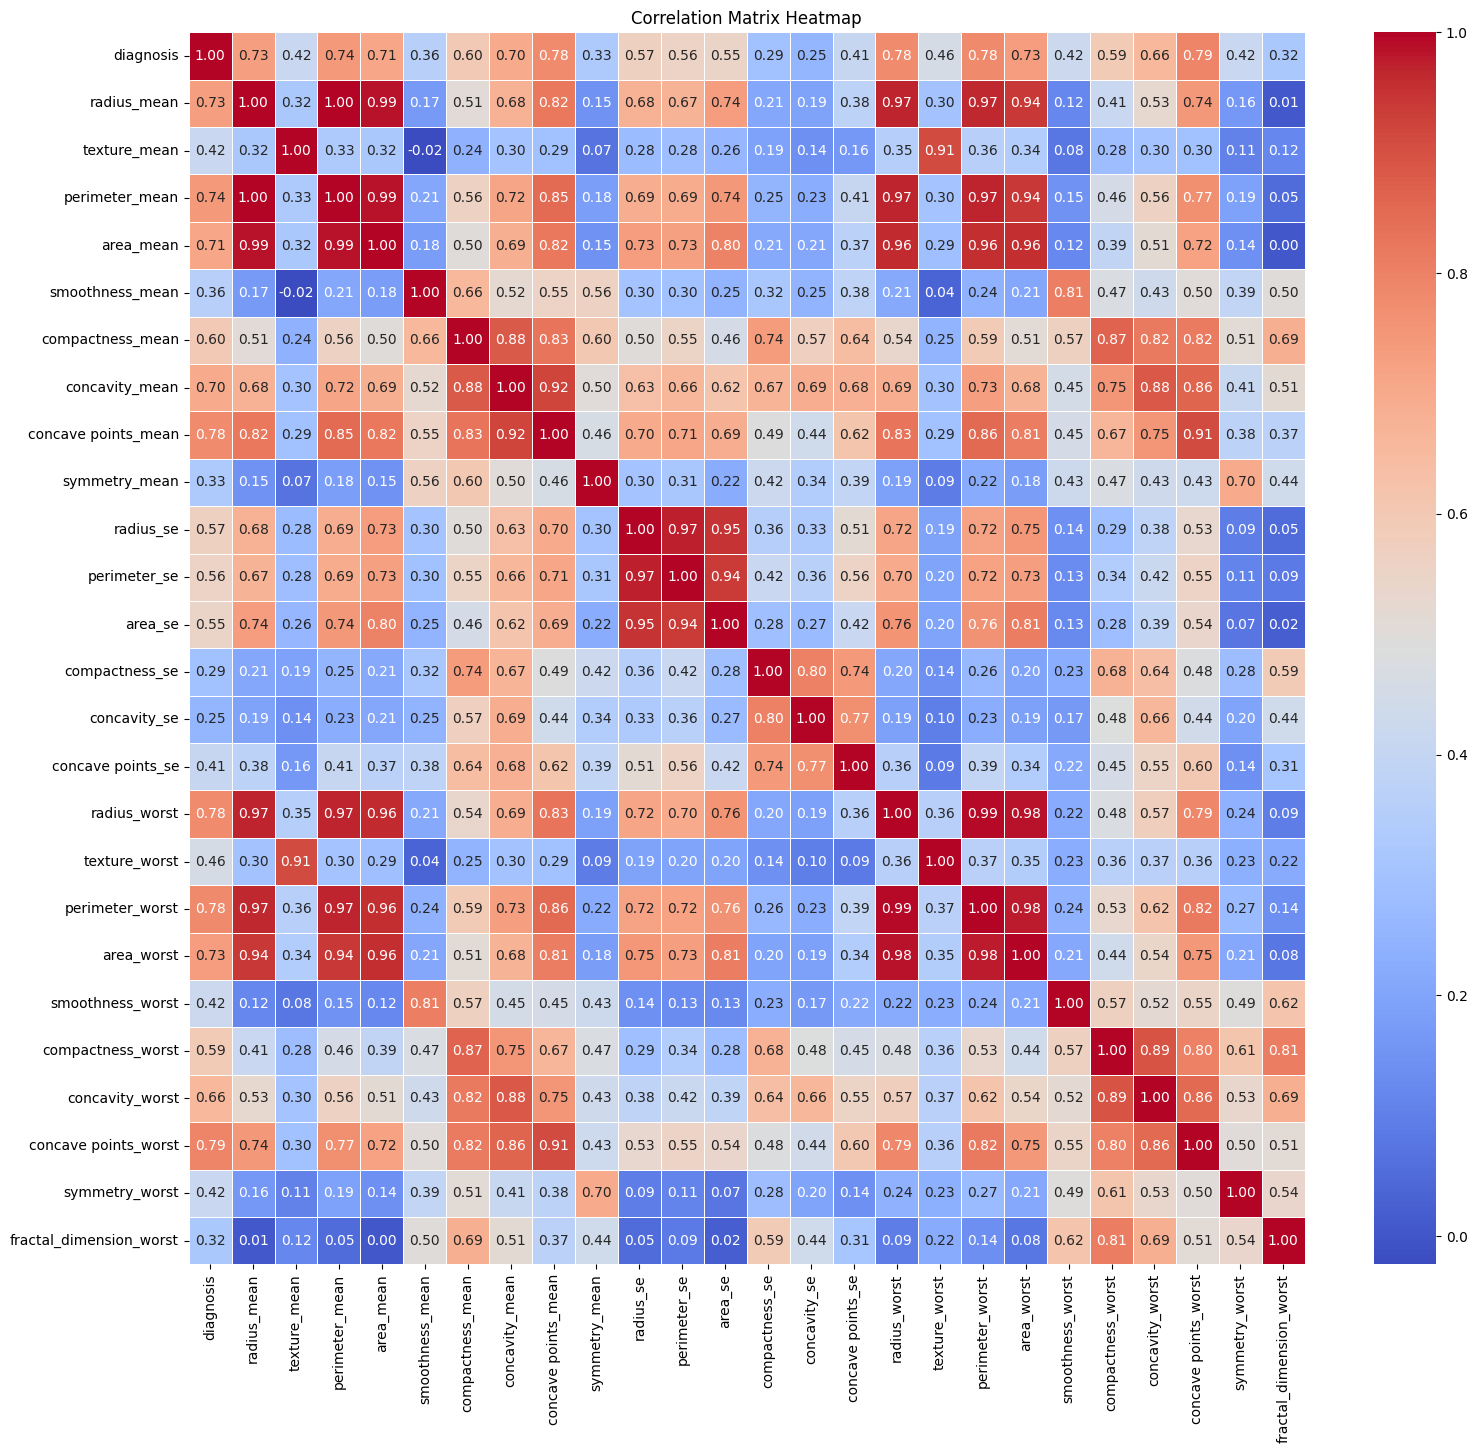

In [117]:
import seaborn as sns
import matplotlib.pyplot as plt
wanted_cols = [item[0] for item in correlated_features_target]
correlation_matrix_show = dataset[wanted_cols].corr()
plt.figure(figsize=(18, 16))
sns.heatmap(correlation_matrix_show, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Correlation Matrix Heatmap')
plt.show()

In [118]:
def are_relations_non_linear(dataset, feature_columns, target_column, correlation_threshold=0.8, len_corr=1):
    columns_to_check = feature_columns + [target_column]
    # Subset the DataFrame
    subset_df = dataset[columns_to_check]
    spearman_corr_matrix = subset_df.corr(method='spearman')
    # Find pairs of highly correlated features and the target
    correlated_features_target = []
    for feature in feature_columns:
        if spearman_corr_matrix.loc[feature, target_column] > correlation_threshold:
            feature_target_pair = (feature, target_column)
            correlated_features_target.append(feature_target_pair)
    is_high_corr = len(correlated_features_target) >= len_corr
    return is_high_corr

In [119]:
spearman_corr_matrix = dataset.corr(method='spearman')
# Find pairs of highly correlated features and the target
correlated_features_target = []
for feature in dataset.columns:
    if spearman_corr_matrix.loc[feature, target_column] > correlation_threshold:
        feature_target_pair = (feature, target_column)
        correlated_features_target.append(feature_target_pair)
is_high_corr = len(correlated_features_target) >= len_corr
is_high_corr

True

In [120]:
spearman_corr_matrix

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
id,1.000000,-0.079866,0.043740,0.125809,0.043374,0.042829,-0.073225,-0.002247,0.000657,-0.003174,...,0.077484,0.026199,0.023137,-0.080853,-0.011300,-0.013284,-0.012798,-0.064977,-0.090637,NaN
diagnosis,-0.079866,1.000000,0.732785,0.461971,0.748496,0.734122,0.371892,0.609288,0.733308,0.777877,...,0.476720,0.796319,0.786902,0.425513,0.606810,0.705734,0.781674,0.396843,0.311477,NaN
radius_mean,0.043740,0.732785,1.000000,0.340956,0.997802,0.999602,0.148510,0.497578,0.645728,0.759702,...,0.314911,0.971555,0.978863,0.125789,0.491357,0.596043,0.727265,0.174698,0.044564,NaN
texture_mean,0.125809,0.461971,0.340956,1.000000,0.348142,0.344145,0.024649,0.266499,0.342646,0.306891,...,0.909218,0.375273,0.368335,0.101401,0.290917,0.339725,0.319235,0.120693,0.116144,NaN
perimeter_mean,0.043374,0.748496,0.997802,0.348142,1.000000,0.997068,0.182923,0.543925,0.681958,0.788629,...,0.323109,0.978980,0.980864,0.156611,0.534565,0.632106,0.757526,0.199007,0.088961,NaN
area_mean,0.042829,0.734122,0.999602,0.344145,0.997068,1.000000,0.138053,0.488988,0.642557,0.755165,...,0.318178,0.971822,0.980264,0.119712,0.485813,0.593736,0.723390,0.170860,0.038758,NaN
smoothness_mean,-0.073225,0.371892,0.148510,0.024649,0.182923,0.138053,1.000000,0.678806,0.518511,0.565172,...,0.060645,0.226345,0.191735,0.796085,0.481384,0.429107,0.498868,0.393579,0.511457,NaN
compactness_mean,-0.002247,0.609288,0.497578,0.266499,0.543925,0.488988,0.678806,1.000000,0.896518,0.848295,...,0.255305,0.592254,0.531590,0.578902,0.901029,0.837921,0.825473,0.450333,0.688986,NaN
concavity_mean,0.000657,0.733308,0.645728,0.342646,0.681958,0.642557,0.518511,0.896518,1.000000,0.927352,...,0.335866,0.722424,0.676628,0.488775,0.849985,0.938543,0.904938,0.383667,0.541838,NaN
concave points_mean,-0.003174,0.777877,0.759702,0.306891,0.788629,0.755165,0.565172,0.848295,0.927352,1.000000,...,0.300562,0.813960,0.780395,0.490035,0.758309,0.827281,0.937075,0.355477,0.421110,NaN


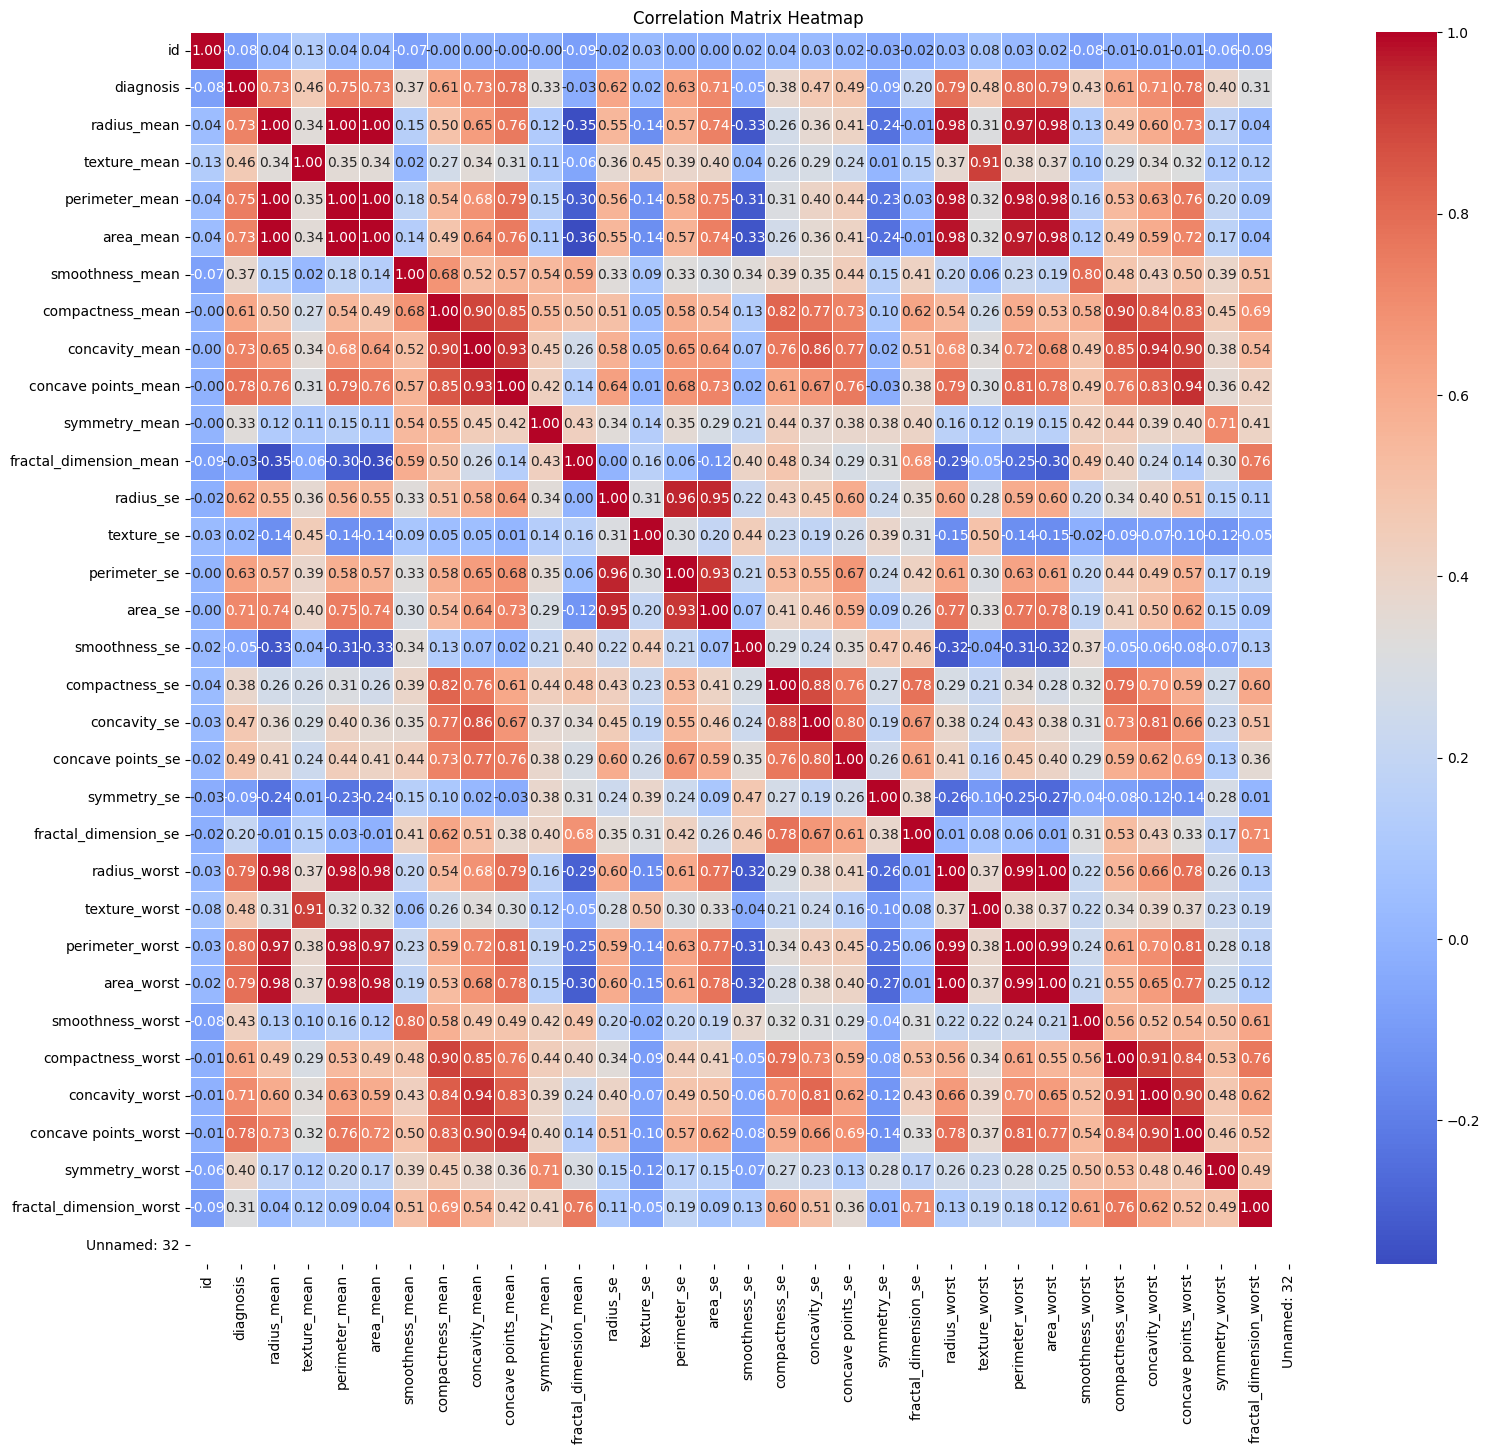

In [121]:
plt.figure(figsize=(18, 16))
sns.heatmap(spearman_corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Correlation Matrix Heatmap')
plt.show()